In [33]:
# ============================================================
# CELL 1 — IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os                  #Loads a system tool to talk to the computer's files and folders
import json
import time
import random
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)                     #Locks all random generators to that anchor, making sure our results are identical every time we run it.
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


In [34]:
# ============================================================
# CELL 2 — LOAD DATA
# ============================================================

df = pd.read_csv('GSPC.csv')

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape: (24801, 7)

Columns:
['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Data Types:
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

Missing Values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Duplicate Rows:
0


In [35]:
# ============================================================
# CELL 3 — DATE PROCESSING
# ============================================================

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())

df.head()


Start Date: 1927-12-30 00:00:00
End Date: 2026-09-25 00:00:00


,Date,Open,High,Low,Close,Adj Close,Volume
0,1927-12-30,17.660000,17.660000,17.660000,17.660000,17.660000,0
1,1928-01-03,17.760000,17.760000,17.760000,17.760000,17.760000,0
2,1928-01-04,17.719999,17.719999,17.719999,17.719999,17.719999,0
3,1928-01-05,17.549999,17.549999,17.549999,17.549999,17.549999,0
4,1928-01-06,17.660000,17.660000,17.660000,17.660000,17.660000,0


In [36]:
# ============================================================
# CELL 6 - REQUIRED COLUMN VALIDATION
# ============================================================

required_columns = [
    "Date",
    "Open",
    "High",
    "Low",
    "Close",
    "Adj Close",
    "Volume"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if len(missing_columns) == 0:
    print("All required columns are present.")
else:
    print("Missing columns:", missing_columns)

All required columns are present.


In [37]:
# ============================================================
# CELL 7 - OHLC VALIDATION
# ============================================================

invalid_ohlc = (
    (df["High"] < df["Low"]) |
    (df["High"] < df["Open"]) |
    (df["High"] < df["Close"]) |
    (df["Low"] > df["Open"]) |
    (df["Low"] > df["Close"])
)

print("Invalid OHLC rows:", invalid_ohlc.sum())


Invalid OHLC rows: 0


In [38]:
# =============================================================
# CELL 8 - MISSING VALUE PLOT
# =============================================================

missing = df.isnull().sum()
print("Missing Values per Column:")
print(missing)

# Only attempt to plot if there is at least one missing value
if missing.sum() > 0:
    plt.figure(figsize=(10, 5))
    missing[missing > 0].plot(kind="bar")
    plt.title("Missing Values by Column")
    plt.xlabel("Columns")
    plt.ylabel("Missing Count")
    plt.show()
else:
    print("\nNo missing values found in the dataset! Skipping plot.")

Missing Values per Column:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

No missing values found in the dataset! Skipping plot.


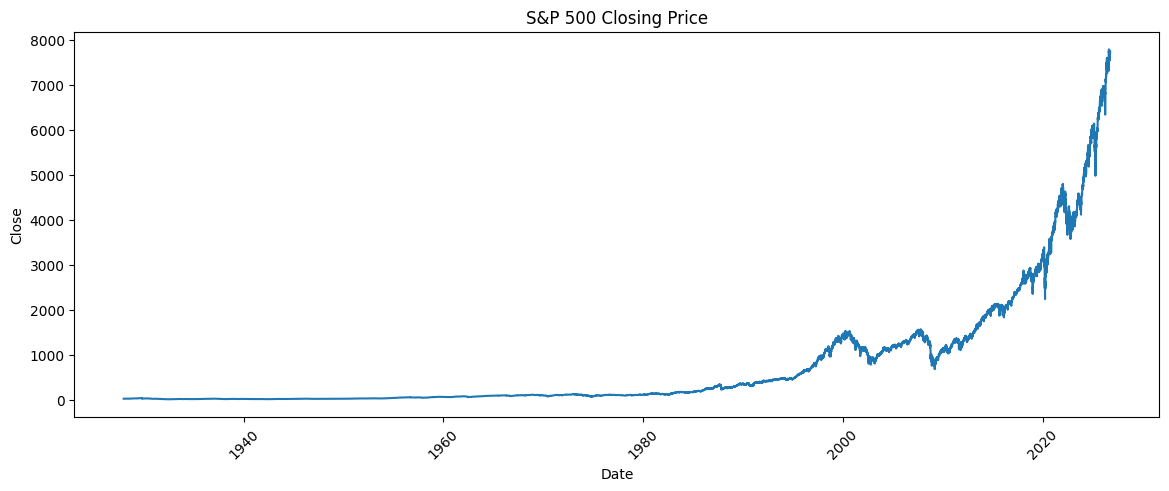

In [39]:
# ============================================================
# CELL 9 - CLOSING PRICE PLOT
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    df["Date"],
    df["Close"]
)

plt.title("S&P 500 Closing Price")
plt.xlabel("Date")
plt.ylabel("Close")
plt.xticks(rotation=45)
plt.show()

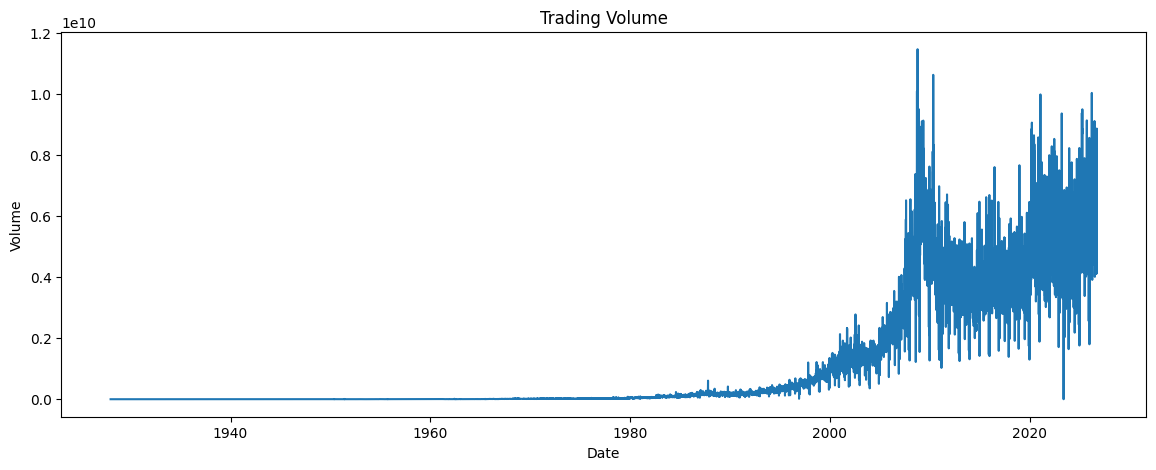

In [40]:
# ============================================================
# CELL 10 - VOLUME PLOT
# ============================================================

plt.figure(figsize=(14, 5))

plt.plot(
    df["Date"],
    df["Volume"]
)

plt.title("Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()



In [41]:
# ============================================================
# CELL 11 - DAILY RETURN
# ============================================================

df["Daily_Return"] = (
    df["Close"].pct_change()
)



In [42]:
# ============================================================
# CELL 12 - PRICE RANGE
# ============================================================

df["Price_Range_Pct"] = (
    (df["High"] - df["Low"])
    / df["Close"]
)

In [43]:
# ============================================================
# CELL 13 - OPEN-CLOSE PERCENTAGE
# ============================================================

df["Open_Close_Pct"] = (
    (df["Close"] - df["Open"])
    / df["Open"]
)

In [44]:
# ============================================================
# CELL 14 - MOVING AVERAGE FEATURES
# ============================================================

df["MA7"] = (
    df["Close"]
    .rolling(7)
    .mean()
)

df["MA20"] = (
    df["Close"]
    .rolling(20)
    .mean()
)

df["Close_MA7_Ratio"] = (
    df["Close"] / df["MA7"]
)

df["Close_MA20_Ratio"] = (
    df["Close"] / df["MA20"]
)

df["MA7_MA20_Cross"] = (
    df["MA7"] / df["MA20"]
)



In [45]:
# ============================================================
# CELL 15 - VOLATILITY
# ============================================================

df["Volatility_20"] = (
    df["Daily_Return"]
    .rolling(20)
    .std()
)


In [46]:
# ============================================================
# CELL 16 - MOMENTUM
# ============================================================

df["Momentum_5"] = (
    df["Close"] / df["Close"].shift(5) - 1
)

df["Momentum_10"] = (
    df["Close"] / df["Close"].shift(10) - 1
)

In [47]:
# ============================================================
# CELL 17 - NEXT-DAY RETURN TARGET
# ============================================================

df["Target_Return"] = (
    df["Close"].shift(-1)
    / df["Close"]
    - 1
)

df[
    [
        "Date",
        "Close",
        "Target_Return"
    ]
].head(10)

,Date,Close,Target_Return
0,1927-12-30,17.660000,0.005663
1,1928-01-03,17.760000,-0.002252
2,1928-01-04,17.719999,-0.009594
3,1928-01-05,17.549999,0.006268
4,1928-01-06,17.660000,-0.009060
5,1928-01-09,17.500000,-0.007429
6,1928-01-10,17.370001,-0.001151
7,1928-01-11,17.350000,0.006916
8,1928-01-12,17.469999,0.006297
9,1928-01-13,17.580000,-0.016496


In [48]:
# ============================================================
# CELL 18 - TREND FUNCTION
# ============================================================

THRESHOLD = 0.005

def return_to_trend(returns, threshold=THRESHOLD):

    return np.select(
        [
            returns > threshold,
            returns < -threshold
        ],
        [
            "Bullish",
            "Bearish"
        ],
        default="Neutral"
    )


In [49]:
# ============================================================
# CELL 19 - DEFINE FEATURES
# ============================================================

FEATURES = [
    "Daily_Return",
    "Price_Range_Pct",
    "Open_Close_Pct",
    "Close_MA7_Ratio",
    "Close_MA20_Ratio",
    "Volatility_20",
    "MA7_MA20_Cross",
    "Momentum_5",
    "Momentum_10"
]

TARGET = "Target_Return"

print("Features:")
for feature in FEATURES:
    print("-", feature)

print("\nNumber of features:", len(FEATURES))


Features:
- Daily_Return
- Price_Range_Pct
- Open_Close_Pct
- Close_MA7_Ratio
- Close_MA20_Ratio
- Volatility_20
- MA7_MA20_Cross
- Momentum_5
- Momentum_10

Number of features: 9


In [50]:
# ============================================================
# CELL 20 - FINAL MODEL DATASET
# ============================================================

model_df = df[
    [
        "Date",
        "Close",
        *FEATURES,
        TARGET
    ]
].copy()

model_df = model_df.dropna().reset_index(drop=True)

print("Final Model Dataset:", model_df.shape)

model_df.head()

Final Model Dataset: (24780, 12)


,Date,Close,Daily_Return,Price_Range_Pct,Open_Close_Pct,Close_MA7_Ratio,Close_MA20_Ratio,Volatility_20,MA7_MA20_Cross,Momentum_5,Momentum_10,Target_Return
0,1928-01-30,17.490000,-0.011306,0.0,0.0,0.994073,0.998430,0.007756,1.004383,-0.008503,0.011567,0.004574
1,1928-01-31,17.570000,0.004574,0.0,0.0,0.997890,1.003541,0.007715,1.005663,-0.007905,0.015607,-0.002277
2,1928-02-01,17.530001,-0.002277,0.0,0.0,0.996508,1.001800,0.007715,1.005311,0.000571,0.015643,0.005704
3,1928-02-02,17.629999,0.005704,0.0,0.0,1.002844,1.007285,0.007523,1.004428,0.000000,0.014384,-0.013046
4,1928-02-03,17.400000,-0.013046,0.0,0.0,0.990727,0.994883,0.007939,1.004194,-0.016393,-0.004577,0.002874


In [51]:
# ============================================================
# CELL 21 - CHRONOLOGICAL SPLIT
# ============================================================

n = len(model_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = model_df.iloc[:train_end].copy()

val_df = model_df.iloc[
    train_end:val_end
].copy()

test_df = model_df.iloc[
    val_end:
].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTRAIN")
print(
    train_df["Date"].min(),
    "->",
    train_df["Date"].max()
)

print("\nVALIDATION")
print(
    val_df["Date"].min(),
    "->",
    val_df["Date"].max()
)

print("\nTEST")
print(
    test_df["Date"].min(),
    "->",
    test_df["Date"].max()
)


Train: (17346, 12)
Validation: (3717, 12)
Test: (3717, 12)

TRAIN
1928-01-30 00:00:00 -> 1997-03-06 00:00:00

VALIDATION
1997-03-07 00:00:00 -> 2011-12-09 00:00:00

TEST
2011-12-12 00:00:00 -> 2026-09-24 00:00:00


In [52]:
# ============================================================
# CELL 22 - PREPARE LINEAR REGRESSION DATA
# ============================================================

X_train = train_df[FEATURES]
y_train = train_df[TARGET]

X_val = val_df[FEATURES]
y_val = val_df[TARGET]

X_test = test_df[FEATURES]
y_test = test_df[TARGET]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)


X_train: (17346, 9)
X_val: (3717, 9)
X_test: (3717, 9)


In [53]:
# ============================================================
# CELL 23 - SCALE FEATURES
# ============================================================

feature_scaler = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(
    X_train
)

X_val_scaled = feature_scaler.transform(
    X_val
)

X_test_scaled = feature_scaler.transform(
    X_test
)

print("Feature scaling completed.")

Feature scaling completed.


In [54]:
# ============================================================
# MODEL 1 - NAIVE PERSISTENCE BASELINE
# ============================================================

# Tomorrow's return is assumed to be 0%.
# Equivalent to: Tomorrow's Price = Today's Price.

naive_train_pred = np.zeros(len(y_train))
naive_val_pred = np.zeros(len(y_val))
naive_test_pred = np.zeros(len(y_test))

print("Naive baseline predictions created.")

Naive baseline predictions created.


In [55]:
# ============================================================
# CELL 25 - REGRESSION METRIC FUNCTION
# ============================================================

def calculate_regression_metrics(
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


In [56]:
# ============================================================
# CELL 26 - NAIVE METRICS
# ============================================================

naive_test_metrics = calculate_regression_metrics(
    y_test,
    naive_test_pred
)

print("NAIVE PERSISTENCE BASELINE")
print("---------------------------")

for key, value in naive_test_metrics.items():
    print(f"{key}: {value:.6f}")

NAIVE PERSISTENCE BASELINE
---------------------------
MAE: 0.006923
RMSE: 0.010484
R2: -0.002746


In [57]:
# ============================================================
# MODEL 2 - LINEAR REGRESSION
# ============================================================

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

print("Linear Regression training completed.")

Linear Regression training completed.


In [58]:
# ============================================================
# CELL 28 - LINEAR REGRESSION PREDICTIONS
# ============================================================

linear_train_pred = linear_model.predict(
    X_train_scaled
)

linear_val_pred = linear_model.predict(
    X_val_scaled
)

linear_test_pred = linear_model.predict(
    X_test_scaled
)

print("Linear Regression predictions completed.")

Linear Regression predictions completed.


In [59]:
# ============================================================
# CELL 29 - LINEAR REGRESSION METRICS
# ============================================================

linear_train_metrics = calculate_regression_metrics(
    y_train,
    linear_train_pred
)

linear_val_metrics = calculate_regression_metrics(
    y_val,
    linear_val_pred
)

linear_test_metrics = calculate_regression_metrics(
    y_test,
    linear_test_pred
)

print("LINEAR REGRESSION - TEST")
print("------------------------")

for key, value in linear_test_metrics.items():
    print(f"{key}: {value:.6f}")


# ============================================================
# CELL 30 - LINEAR REGRESSION TREND ACCURACY
# ============================================================

linear_actual_trend = return_to_trend(
    y_test.values
)

linear_predicted_trend = return_to_trend(
    linear_test_pred
)

linear_trend_accuracy = accuracy_score(
    linear_actual_trend,
    linear_predicted_trend
)

print(
    "Linear Regression Trend Accuracy:",
    f"{linear_trend_accuracy * 100:.2f}%"
)

LINEAR REGRESSION - TEST
------------------------
MAE: 0.006995
RMSE: 0.010637
R2: -0.032182
Linear Regression Trend Accuracy: 51.92%
